# GliZNet Forward Pass — Cosine Similarity at Each Stage

Step-by-step visualization of how label and text representations relate through the aggregator.

The new architecture is simple:

| Stage | Labels | Text repr |
|-------|--------|-----------|
| 1. Raw | `[LAB]` token embeddings | CLS token (position 0) |
| 2. After Context Fusion | Same `[LAB]` embeddings (used as query) | `LabelContextFusion` output — labels attend to peer fused(CLS+label) views |

**Key insight**: The bilinear head scores `(context_text_repr, label_emb)` pairs. The text representation is produced by label interaction — each label sees how peers interpret the shared CLS.


In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from gliznet import GliZNetForSequenceClassification, GliZNETTokenizer

# Select GPU with most free memory
DEVICE = "cpu"
if torch.cuda.is_available():
    best_gpu, best_mem = 0, 0
    for i in range(torch.cuda.device_count()):
        try:
            free = torch.cuda.mem_get_info(i)[0]
            if free > best_mem:
                best_gpu, best_mem = i, free
        except RuntimeError:
            continue
    if best_mem > 0:
        DEVICE = f"cuda:{best_gpu}"

MODEL_PATH = "../results/modernbert_base_20260522_033252/checkpoint-40000"

model = GliZNetForSequenceClassification.from_pretrained(
    MODEL_PATH,
).to(DEVICE, dtype=torch.float16).eval()
tokenizer = GliZNETTokenizer.from_pretrained(MODEL_PATH)

print(f"Device: {DEVICE}")
print(f"Model loaded from: {MODEL_PATH}")
print(f"Hidden size: {model.aggregator.hidden_size}")
print(f"Scoring: {model.aggregator.scoring.__class__.__name__}")
print(f"Label context: {model.aggregator.label_context is not None}")

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Device: cuda:1
Model loaded from: ../results/modernbert_base_20260522_033252/checkpoint-40000
Hidden size: 768
Scoring: BilinearScoring
Label context: True


In [ ]:
# Define a sample text with labels (mix of true and false)
text = "New research shows that moderate coffee consumption may reduce the risk of Alzheimer's disease by up to 30%."
labels = ["medical_research", "nutrition_advice", "drug_development", "disease_prevention", "public_health_policy"]
expected = [True, False, False, True, False]

text = "After years of training and countless sacrifices, the athlete finally stood on the Olympic podium, tears streaming down her face as the national anthem played."
labels = ["athletic_achievement", "personal_sacrifice", "patriotism", "emotional_moment", "celebrity_gossip", "sports_injury", "political_protest", "entertainment_review", "historical_analysis", "travel_experience"]
expected = [True, True, True, True, False, False, False, False, False, False]

text = "The Board of Directors has approved a dividend of $1.25 per share, payable on June 15 to shareholders of record as of May 31."
labels = ["shareholder_communication", "financial_regulation", "investment_advice", "corporate_governance", "market_analysis"]
expected = [True, False, False, True, False]

text = "The building's facade combines Art Deco geometric patterns with Brutalist concrete massing, creating a jarring but oddly compelling visual tension."
labels = ["architecture_criticism", "building_description", "design_theory", "urban_planning", "real_estate_listing"]
expected = [True, True, True, False, False]

text = "Temperatures are expected to reach 42°C by Thursday, with humidity levels above 80%. Authorities have issued a heat advisory for the metropolitan area."
labels = ["weather_forecast", "climate_change", "public_safety_warning", "natural_disaster", "environmental_report"]
expected = [True, False, True, False, False]

text = "Thank you for your years of service. Your dedication to this team has been exceptional, and while we're sad to see you go, we wish you all the best in your next chapter"
labels = ["farewell_message", "performance_evaluation", "retirement_announcement", "termination_notice", "professional_recommendation"]
expected = [True, False, False, False, False]

# ── very_X intensity/level labels ────────────────────────────────────────────
# The label set defines a scale; the text determines which level applies.
# Hierarchy: very_positive → positive, very_negative → negative

# Strongly positive product review
text = "This is hands down the best purchase I've ever made. Completely transformed my daily routine — I can't imagine life without it. Five stars, would buy a hundred times over."
labels = ["very_positive", "positive", "neutral", "negative", "very_negative"]
expected = [True, True, False, False, False]  # very_positive implies positive

# Mildly positive
text = "Overall a decent product. Does what it says, arrived on time, and the quality seems fine for the price. Nothing spectacular but no complaints either."
labels = ["very_positive", "positive", "neutral", "negative", "very_negative"]
expected = [False, True, False, False, False]

# Neutral / informational
text = "The package contains one unit, weighing approximately 450 grams. Compatible with models manufactured after 2018. Instructions included in English and French."
labels = ["very_positive", "positive", "neutral", "negative", "very_negative"]
expected = [False, False, True, False, False]

# Mildly negative
# text = "The product works but the build quality feels cheap and the instructions are confusing. Expected better for the price."
# labels = ["very_positive", "positive", "neutral", "negative", "very_negative"]
# expected = [False, False, False, True, False]

# Strongly negative
# text = "Absolute garbage. Broke after two days, customer support ignored my emails, and the return process is a nightmare. Complete waste of money — avoid at all costs."
# labels = ["very_positive", "positive", "neutral", "negative", "very_negative"]
# expected = [False, False, False, True, True]  # very_negative implies negative

# Tokenize
batch = tokenizer([(text, labels)], return_tensors="pt")
batch = {k: v.to(DEVICE) for k, v in batch.items()}

print(f"Input shape: {batch['input_ids'].shape}")
print(f"Labels: {labels}")
print(f"\nExpected true:  {[l for l, e in zip(labels, expected) if e]}")
print(f"Expected false: {[l for l, e in zip(labels, expected) if not e]}")


Input shape: torch.Size([1, 38])
Labels: ['very_positive', 'positive', 'neutral', 'negative', 'very_negative']

Expected true:  ['negative']
Expected false: ['very_positive', 'positive', 'neutral', 'very_negative']


## Capture All Stages

Follows `LabelAggregator.forward()` exactly:
1. Normalize hidden states to unit norm
2. Compute text_mask, aggregate [LAB] embeddings
3. First-pass text pooling (cross-attention: labels over text tokens)
4. Label context enrichment (labels attend to peers + their text evidence)
5. Second-pass text pooling (with enriched labels)
6. Bilinear scoring

In [3]:
@torch.no_grad()
def get_all_stages(model, batch, labels):
    """Run the forward pass step by step, matching LabelAggregator.forward() exactly."""
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    lmask = batch["lmask"]

    # Stage 1: Encoder + unit-norm normalization
    encoder_output = model.backbone(input_ids=input_ids, attention_mask=attention_mask)
    hidden_states = encoder_output.last_hidden_state  # (B, L, D)
    hidden_states = F.normalize(hidden_states, p=2, dim=-1)

    agg = model.aggregator
    B, L, D = hidden_states.shape

    # Text mask: text tokens only (no label tokens, no padding)
    lab_token_mask = input_ids == agg.lab_token_id
    text_mask = (lmask == 0) & (attention_mask == 1) & (~lab_token_mask)

    # Stage 2: Aggregate labels (extracts [LAB] token embeddings, dropout in train)
    aggregated_labels, all_batch_ids, all_label_ids, max_k = agg.aggregate_labels(
        input_ids, hidden_states
    )

    # Build dense label tensor
    dense_labels = aggregated_labels.new_zeros(B, max_k, D)
    dense_labels[all_batch_ids, all_label_ids - 1] = aggregated_labels

    # Stage 3+4: Label context enrichment (if enabled)
    dense_text_first = None
    if agg.label_context is not None:
        label_mask = torch.zeros(B, max_k, dtype=torch.bool, device=hidden_states.device)
        label_mask[all_batch_ids, all_label_ids - 1] = True

        # Round 1: independent text pooling (each label attends to text tokens)
        dense_text_first = agg._text_repr_dense(dense_labels, hidden_states, text_mask)

        # Cooperative enrichment: labels attend to peers + their text evidence
        dense_labels = agg.label_context(dense_labels, dense_text_first, label_mask)

        # Gather enriched label embeddings
        aggregated_labels = dense_labels[all_batch_ids, all_label_ids - 1]

    # Stage 5: Text representation (cross-attention over text tokens)
    aggregated_text = agg._text_repr(
        dense_labels, hidden_states, text_mask, all_batch_ids, all_label_ids
    )

    # Stage 6: Scoring
    logits = agg.scoring(aggregated_text, aggregated_labels)
    scores = torch.sigmoid(logits).squeeze(-1)

    # CLS for reference
    cls_emb = hidden_states[0, 0]

    # Raw [LAB] positions (before enrichment, after normalization)
    lab_positions = lab_token_mask[0].nonzero(as_tuple=True)[0]
    raw_label_embs = hidden_states[0, lab_positions]

    return {
        # Raw encoder (unit-norm)
        "hidden_states": hidden_states,          # (B, L, D)
        "cls_emb": cls_emb,                      # (D,)
        "raw_label_embs": raw_label_embs,        # (K, D)
        "text_mask": text_mask,                  # (B, L)
        # After aggregation + enrichment
        "agg_label_embs": aggregated_labels,     # (N, D)
        # First-pass text pooling (before enrichment)
        "dense_text_first": dense_text_first,    # (B, K, D) or None
        # Final text representation (cross-attention output)
        "text_repr": aggregated_text,            # (N, D)
        # Scores
        "logits": logits.squeeze(-1),
        "scores": scores,
        "labels": labels,
    }

stages = get_all_stages(model, batch, labels)
print("All stages captured.")
print(f"  Raw labels:       {stages['raw_label_embs'].shape}")
print(f"  Agg labels:       {stages['agg_label_embs'].shape}")
print(f"  Text repr:        {stages['text_repr'].shape}")
print(f"  First text pool:  {stages['dense_text_first'].shape if stages['dense_text_first'] is not None else 'None'}")

All stages captured.
  Raw labels:       torch.Size([5, 768])
  Agg labels:       torch.Size([5, 768])
  Text repr:        torch.Size([5, 768])
  First text pool:  torch.Size([1, 5, 768])


In [4]:
def cos_sim(a, b):
    """Cosine similarity between vectors/matrices."""
    a = F.normalize(a.float(), p=2, dim=-1)
    b = F.normalize(b.float(), p=2, dim=-1)
    return (a @ b.T).detach().cpu().numpy()


def l2_dist(a, b):
    """Pairwise L2 distance between vectors."""
    a, b = a.float(), b.float()
    return torch.cdist(a.unsqueeze(0), b.unsqueeze(0)).squeeze(0).detach().cpu().numpy()


def bilinear_matrix(scoring, text, labels):
    """Compute full bilinear score matrix: score(text_i, label_j) for all i,j."""
    K = labels.shape[0]
    scores = torch.zeros(K, K)
    for i in range(K):
        text_i = text[i:i+1].expand(K, -1)  # (K, D)
        scores[i] = scoring(text_i, labels).squeeze(-1).detach()
    return scores.cpu().numpy()


print("Helpers ready.")

Helpers ready.


## Label ↔ Text Representations

Since all hidden states are L2-normalized, cosine = dot product and IS meaningful.

- **cos(label, CLS)**: How each [LAB] token relates to global text summary
- **cos(label, text_repr)**: How each enriched label relates to its cross-attention text pooling
- **cos(raw_label, enriched_label)**: How much enrichment changed the label direction

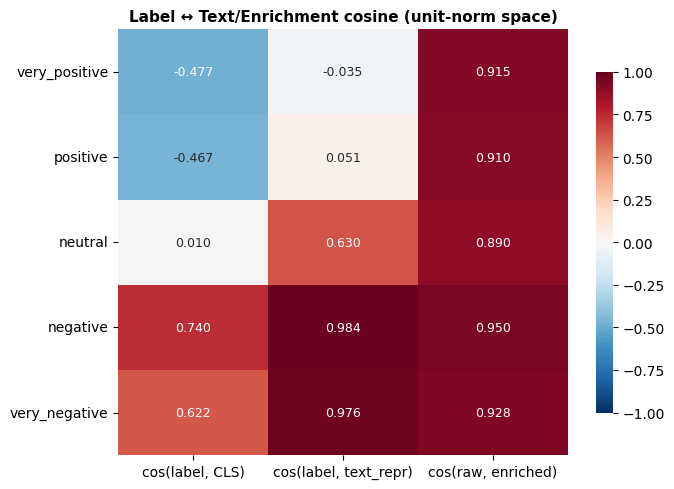


Label                        ↔CLS   ↔text  raw↔enr   Exp
───────────────────────────────────────────────────────
very_positive              -0.477  -0.035    0.915     F
positive                   -0.467   0.051    0.910     F
neutral                     0.010   0.630    0.890     F
negative                    0.740   0.984    0.950     T
very_negative               0.622   0.976    0.928     F


In [5]:
cls = stages["cls_emb"].unsqueeze(0)  # (1, D)

# Each label vs CLS
sim_label_cls = cos_sim(stages["agg_label_embs"], cls).flatten()

# Each label vs its text representation
sim_label_text = np.array([
    cos_sim(stages["agg_label_embs"][i:i+1], stages["text_repr"][i:i+1]).item()
    for i in range(len(labels))
])

# Raw vs enriched label (how much did enrichment change direction?)
sim_raw_enriched = np.array([
    cos_sim(stages["raw_label_embs"][i:i+1], stages["agg_label_embs"][i:i+1]).item()
    for i in range(len(labels))
])

# Heatmap
sim_matrix = np.column_stack([sim_label_cls, sim_label_text, sim_raw_enriched])
stage_cols = ["cos(label, CLS)", "cos(label, text_repr)", "cos(raw, enriched)"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    sim_matrix, ax=ax, vmin=-1, vmax=1, cmap="RdBu_r",
    xticklabels=stage_cols, yticklabels=labels,
    annot=True, fmt=".3f", annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Label ↔ Text/Enrichment cosine (unit-norm space)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

# Table
print(f"\n{'Label':<25} {'↔CLS':>7} {'↔text':>7} {'raw↔enr':>8} {'Exp':>5}")
print("─" * 55)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    print(f"{lbl:<25} {sim_label_cls[i]:>7.3f} {sim_label_text[i]:>7.3f} {sim_raw_enriched[i]:>8.3f} {'T' if exp else 'F':>5}")

## Cross-Attention Weights: Labels over Text Tokens

This IS the aggregator's `_text_repr` mechanism: each label attends to text tokens via
`labels @ hidden_states.T * temperature → softmax`. Visualizes which text tokens each label focuses on.

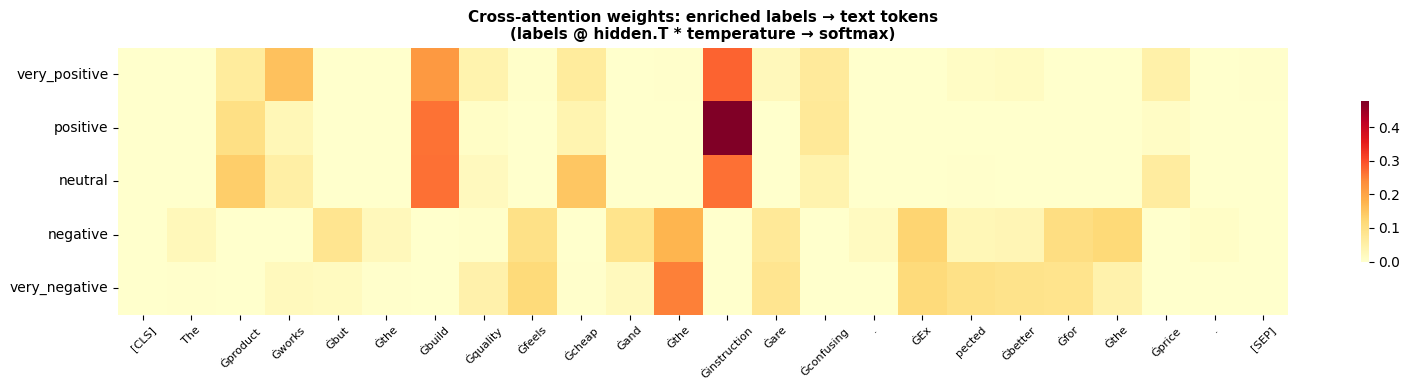

In [6]:
# Compute attention weights exactly as _text_repr_dense does
agg = model.aggregator
hidden_states = stages["hidden_states"]
text_mask = stages["text_mask"]

# Use enriched labels (same as forward pass second-pass)
dense_labels = stages["agg_label_embs"].unsqueeze(0)  # (1, K, D)
scale = agg.attn_temperature.exp()
scores = torch.bmm(dense_labels, hidden_states.transpose(1, 2)) * scale  # (1, K, L)
scores.masked_fill_(~text_mask.unsqueeze(1), float("-inf"))
attn_weights = F.softmax(scores, dim=2)  # (1, K, L)

# Extract text token positions for visualization
text_positions = text_mask[0].nonzero(as_tuple=True)[0]
attn_over_text = attn_weights[0, :, text_positions].detach().cpu().numpy()  # (K, T)

# Token strings
token_ids = batch["input_ids"][0, text_positions].cpu().tolist()
token_strs = tokenizer.tokenizer.convert_ids_to_tokens(token_ids)
token_strs = [t.replace("▁", "")[:12] for t in token_strs]

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    attn_over_text, ax=ax, cmap="YlOrRd", vmin=0,
    xticklabels=token_strs, yticklabels=labels,
    cbar_kws={"shrink": 0.6},
)
ax.set_title("Cross-attention weights: enriched labels → text tokens\n"
             "(labels @ hidden.T * temperature → softmax)",
             fontsize=11, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

## Pairwise Analysis

1. **Label ↔ Label cosine** — How enriched label embeddings relate (unit-norm, so cosine is meaningful)
2. **Text repr ↔ Text repr cosine** — Whether cross-attention produces differentiated text views
3. **Bilinear score matrix** — `bilinear(text_repr_i, label_j)` — the full scoring surface

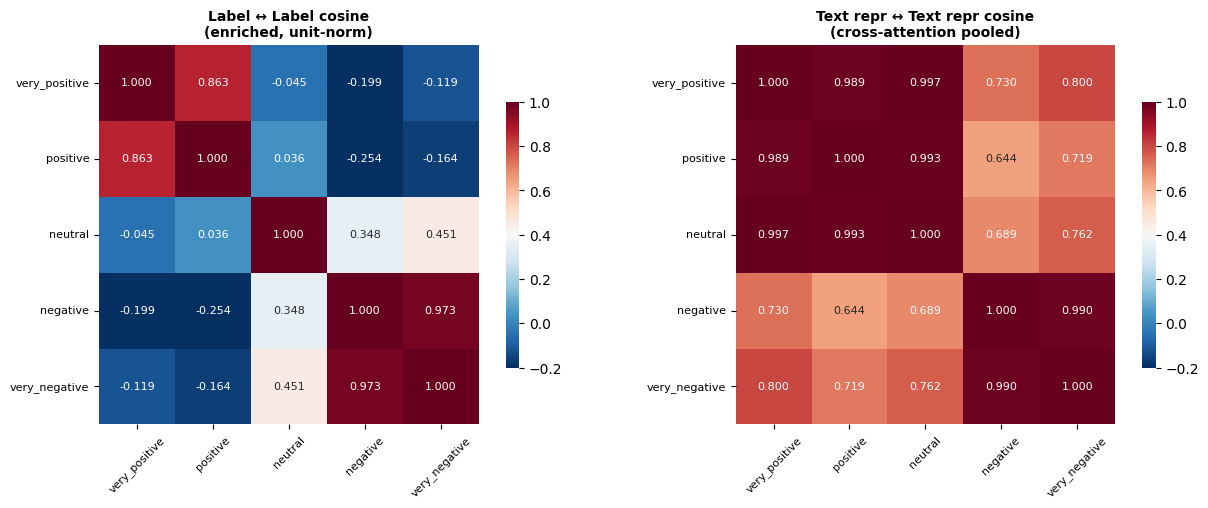

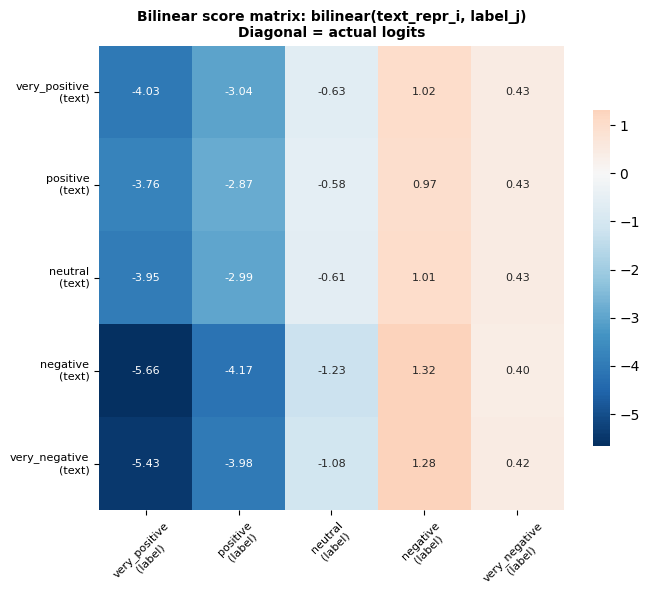


Diagonal — matched pairs (= model logits):
Label                     bilinear(i,i)  model logit   Expected
─────────────────────────────────────────────────────────────────
very_positive                    -4.027       -4.027      FALSE
positive                         -2.869       -2.869      FALSE
neutral                          -0.613       -0.613      FALSE
negative                          1.320        1.320       TRUE
very_negative                     0.425        0.425      FALSE


In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# 1. LABEL ↔ LABEL cosine (enriched labels are unit-norm)
# ──────────────────────────────────────────────────────────────────────────────
sim_ll = cos_sim(stages["agg_label_embs"], stages["agg_label_embs"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    sim_ll, ax=axes[0], vmin=-0.2, vmax=1.0, cmap="RdBu_r",
    xticklabels=labels, yticklabels=labels,
    annot=True, fmt=".3f", annot_kws={"size": 8},
    square=True, cbar_kws={"shrink": 0.7},
)
axes[0].set_title("Label ↔ Label cosine\n(enriched, unit-norm)", fontsize=10, fontweight="bold")
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", rotation=0, labelsize=8)

# Text repr ↔ Text repr
sim_tt = cos_sim(stages["text_repr"], stages["text_repr"])
sns.heatmap(
    sim_tt, ax=axes[1], vmin=-0.2, vmax=1.0, cmap="RdBu_r",
    xticklabels=labels, yticklabels=labels,
    annot=True, fmt=".3f", annot_kws={"size": 8},
    square=True, cbar_kws={"shrink": 0.7},
)
axes[1].set_title("Text repr ↔ Text repr cosine\n(cross-attention pooled)", fontsize=10, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# 2. BILINEAR SCORE MATRIX
#    Diagonal = matched (text_repr_i, label_i) = actual logits
#    Off-diagonal = what-if: text_repr_i scored against label_j
# ──────────────────────────────────────────────────────────────────────────────
score_matrix = bilinear_matrix(model.aggregator.scoring, stages["text_repr"], stages["agg_label_embs"])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    score_matrix, ax=ax, cmap="RdBu_r", center=0,
    xticklabels=[f"{l}\n(label)" for l in labels],
    yticklabels=[f"{l}\n(text)" for l in labels],
    annot=True, fmt=".2f", annot_kws={"size": 8},
    square=True, cbar_kws={"shrink": 0.7},
)
ax.set_title("Bilinear score matrix: bilinear(text_repr_i, label_j)\n"
             "Diagonal = actual logits",
             fontsize=10, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

# Print diagonal
print("\nDiagonal — matched pairs (= model logits):")
print(f"{'Label':<25} {'bilinear(i,i)':>13} {'model logit':>12} {'Expected':>10}")
print("─" * 65)
logits_np = stages["logits"].cpu().numpy()
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    print(f"{lbl:<25} {score_matrix[i, i]:>13.3f} {logits_np[i]:>12.3f} {'TRUE' if exp else 'FALSE':>10}")

## Final Scores

`bilinear(text_repr, label_emb)` → logit → sigmoid.

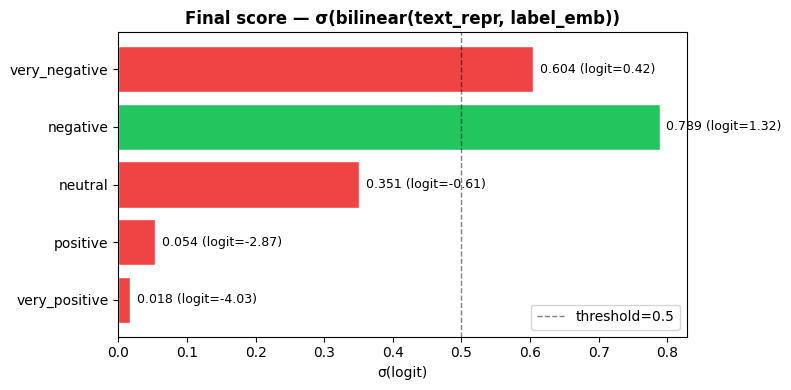


Label                     ↔CLS   ↔text   Logit      σ  Exp
───────────────────────────────────────────────────────
very_positive           -0.477  -0.035   -4.03  0.018   F ✓
positive                -0.467   0.051   -2.87  0.054   F ✓
neutral                  0.010   0.630   -0.61  0.351   F ✓
negative                 0.740   0.984    1.32  0.789   T ✓
very_negative            0.622   0.976    0.42  0.604   F ✗


In [8]:
# Final scores
final_scores = stages["scores"].cpu().numpy()
final_logits = stages["logits"].cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#22c55e" if e else "#ef4444" for e in expected]
ax.barh(labels, final_scores, color=colors, edgecolor="white")
ax.set_xlabel("σ(logit)")
ax.set_title("Final score — σ(bilinear(text_repr, label_emb))", fontweight="bold")
ax.axvline(0.5, color="black", ls="--", lw=1, alpha=0.5, label="threshold=0.5")
ax.legend()
for i, (v, l) in enumerate(zip(final_scores, final_logits)):
    ax.text(v + 0.01, i, f"{v:.3f} (logit={l:.2f})", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# Full table
print(f"\n{'Label':<22} {'↔CLS':>7} {'↔text':>7} {'Logit':>7} {'σ':>6} {'Exp':>4}")
print("─" * 55)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    mark = "✓" if (final_scores[i] > 0.5) == exp else "✗"
    print(f"{lbl:<22} {sim_label_cls[i]:>7.3f} {sim_label_text[i]:>7.3f} "
          f"{final_logits[i]:>7.2f} {final_scores[i]:>6.3f} {'T' if exp else 'F':>3} {mark}")

## Trajectory: Label↔Text Cosine Through Pipeline

Each line traces one label's cosine with its text representation at each stage:
1. Raw label vs CLS (shared, before enrichment)
2. Enriched label vs first-pass text pooling
3. Enriched label vs final text repr (second-pass cross-attention)

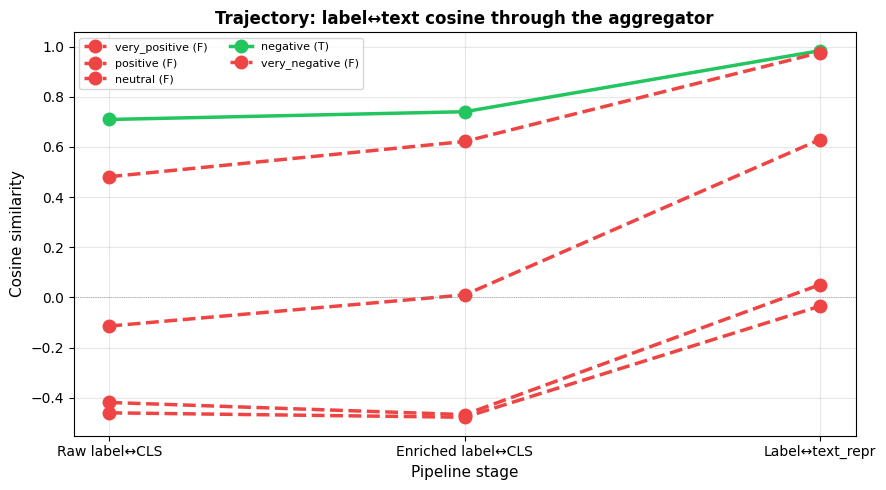


Label                    raw↔CLS   enr↔CLS   ↔text  Δ(raw→text)
──────────────────────────────────────────────────────────────
very_positive             -0.460    -0.477  -0.035       +0.425
positive                  -0.418    -0.467   0.051       +0.469
neutral                   -0.114     0.010   0.630       +0.743
negative                   0.710     0.740   0.984       +0.274
very_negative              0.481     0.622   0.976       +0.495


In [9]:
# Trajectory: label↔text cosine at each stage
stage_names = ["Raw label↔CLS", "Enriched label↔CLS", "Label↔text_repr"]

# Raw label vs CLS
sim_raw_cls = cos_sim(stages["raw_label_embs"], cls).flatten()
# Enriched label vs CLS
sim_enr_cls = sim_label_cls  # already computed
# Enriched label vs its text_repr
sim_enr_text = sim_label_text  # already computed

trajectory = np.column_stack([sim_raw_cls, sim_enr_cls, sim_enr_text])

fig, ax = plt.subplots(figsize=(9, 5))

for i, (lbl, exp) in enumerate(zip(labels, expected)):
    color = "#22c55e" if exp else "#ef4444"
    ls = "-" if exp else "--"
    ax.plot(stage_names, trajectory[i], marker="o", color=color, ls=ls,
            lw=2.5, markersize=9, label=f"{lbl} ({'T' if exp else 'F'})")

ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_ylabel("Cosine similarity", fontsize=11)
ax.set_xlabel("Pipeline stage", fontsize=11)
ax.set_title("Trajectory: label↔text cosine through the aggregator",
             fontweight="bold", fontsize=12)
ax.legend(loc="best", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Delta table
print(f"\n{'Label':<22} {'raw↔CLS':>9} {'enr↔CLS':>9} {'↔text':>7} {'Δ(raw→text)':>12}")
print("─" * 62)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    delta = trajectory[i, 2] - trajectory[i, 0]
    print(f"{lbl:<22} {trajectory[i,0]:>9.3f} {trajectory[i,1]:>9.3f} {trajectory[i,2]:>7.3f} {delta:>+12.3f}")